In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing


# Load the california dataset from skleran as a dataframe
cali = fetch_california_housing(as_frame=True)
df = cali.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [41]:
# Display dataset info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


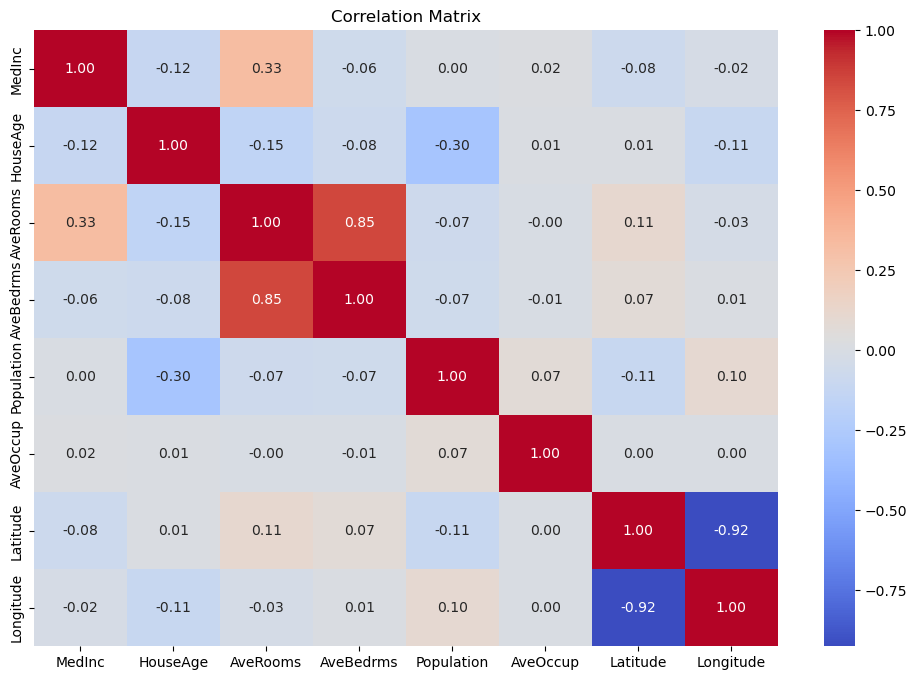

In [42]:
# Visualize correlations
plt.figure(figsize=(12, 8))

corr = df.drop("MedHouseVal", axis=1).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

* High Correlation between AveRooms and AveBedrms

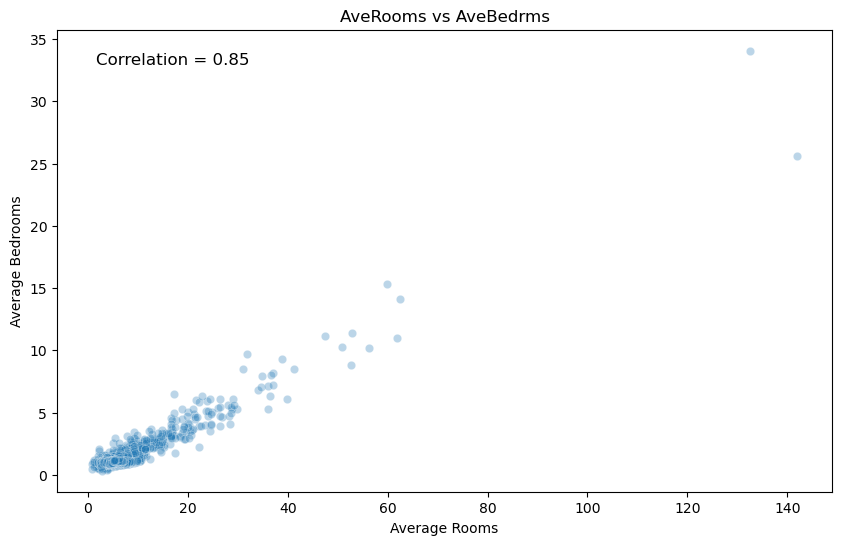


VIF:
    Variable        VIF
0   AveRooms  20.047356
1  AveBedrms  20.047356


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Correlation
corr = df["AveRooms"].corr(df["AveBedrms"])

# Scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="AveRooms",
    y="AveBedrms",
    alpha=0.3
)

plt.xlabel("Average Rooms")
plt.ylabel("Average Bedrooms")
plt.title("AveRooms vs AveBedrms")

# Display correlation on plot
plt.text(
    0.05, 0.95,
    f"Correlation = {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.show()


# VIF
X = df[["AveRooms", "AveBedrms"]]

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

print("\nVIF:")
print(vif)

* High MultiCollineartiy

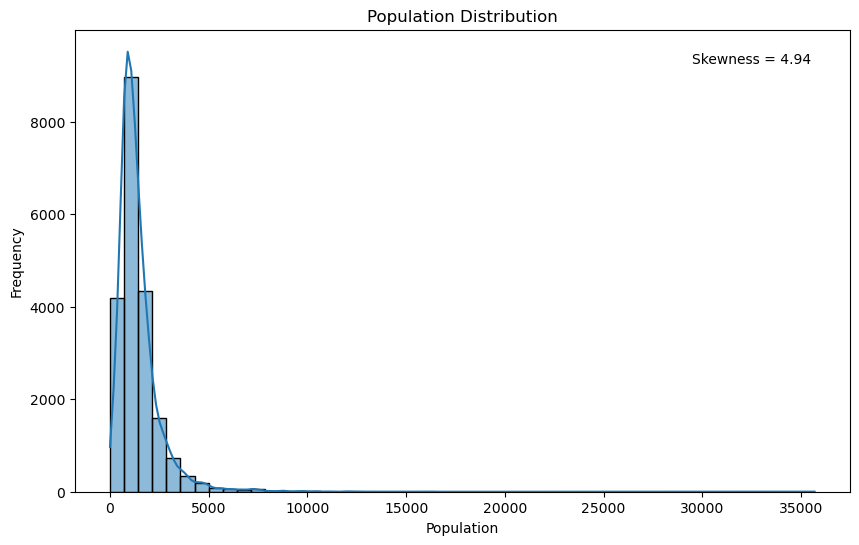

Minimum: 3.0
Maximum: 35682.0
Standard Deviation: 1132.46


In [44]:
# Population analysis

population = df["Population"]

# Skewness
skewness = population.skew()


# Histogram
plt.figure(figsize=(10, 6))

sns.histplot(population, bins=50, kde=True)

plt.xlabel("Population")
plt.ylabel("Frequency")
plt.title("Population Distribution")

# Display skewness on histogram
plt.text(
    0.95, 0.95,
    f"Skewness = {skewness:.2f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top"
)

plt.show()

# Numerical statistics
print(f"Minimum: {population.min()}")
print(f"Maximum: {population.max()}")
print(f"Standard Deviation: {population.std():.2f}")

* Data has high skewness

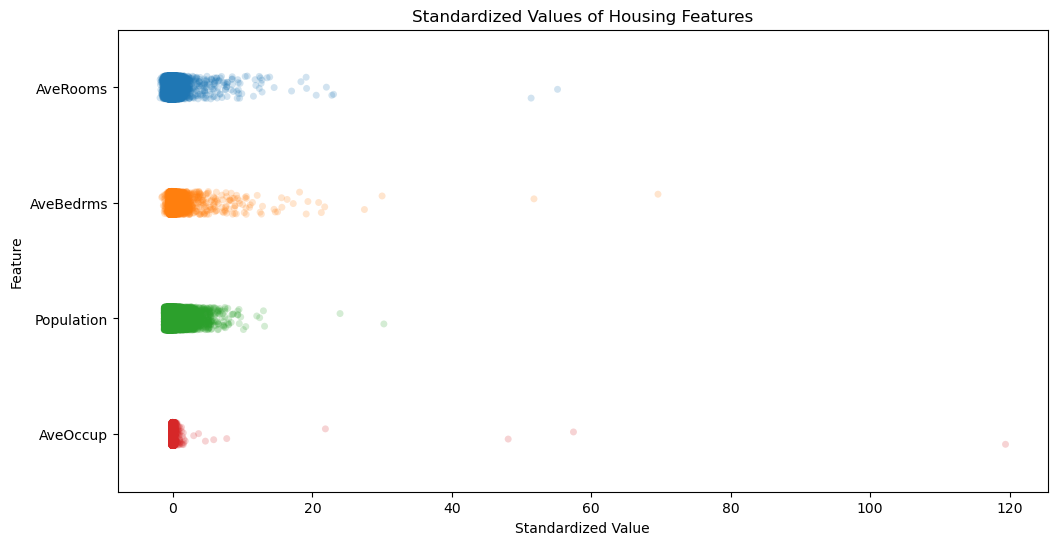

In [45]:
features = ["AveRooms", "AveBedrms", "Population", "AveOccup"]

# Standardize only for visualization
plot_data = df[features].copy()

for col in features:
    plot_data[col] = (
        plot_data[col] - plot_data[col].mean()
    ) / plot_data[col].std()

plt.figure(figsize=(12, 6))

sns.stripplot(
    data=plot_data,
    orient="h",
    alpha=0.2,
    jitter=True
)

plt.title("Standardized Values of Housing Features")
plt.xlabel("Standardized Value")
plt.ylabel("Feature")

plt.show()

* Remove outliers

In [53]:
remove_rows = (plot_data > 20).any(axis=1)

df = df.loc[~remove_rows].copy()

* Check skewness of population again

In [58]:
df[["AveRooms", "AveBedrms", "Population", "AveOccup"]].skew()

AveRooms       7.208810
AveBedrms     13.069958
Population    -1.045512
AveOccup      26.642179
dtype: float64

* Apply log Transformation to population

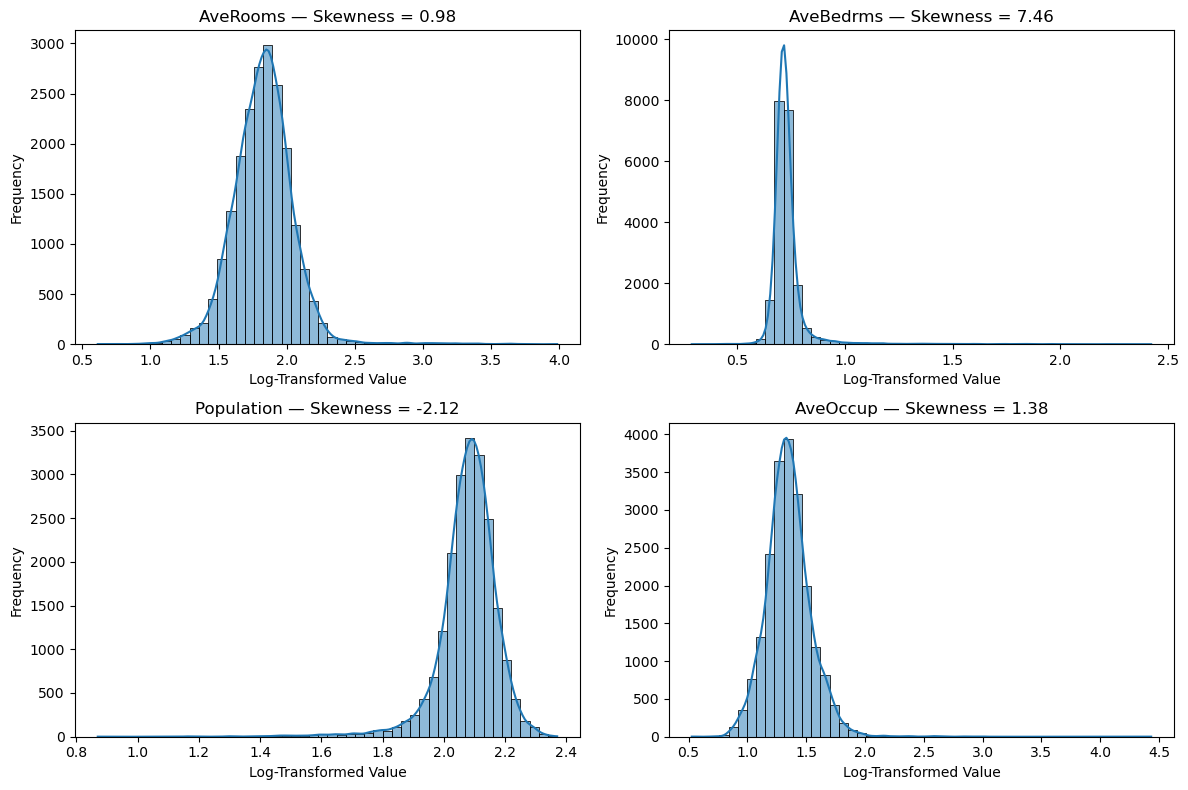

In [59]:
columns = ["AveRooms", "AveBedrms", "Population", "AveOccup"]

# Apply log transformation and update the original columns
df[columns] = np.log1p(df[columns])

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, ax in zip(columns, axes.ravel()):
    skewness = df[col].skew()

    sns.histplot(df[col], bins=50, kde=True, ax=ax)

    ax.set_title(f"{col} — Skewness = {skewness:.2f}")
    ax.set_xlabel("Log-Transformed Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define target and features, the target is MedHouseVAL
y = df["MedHouseVal"]
X = df.drop("MedHouseVal", axis=1)

# Train-test split 80%, 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [48]:
from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso, Ridge
from sklearn.metrics import mean_squared_error

# Initialize models
model_lr = LinearRegression()
model_sgd = SGDRegressor(random_state=42)
model_lasso = Lasso()
model_ridge = Ridge()

# Fit models
model_lr.fit(X_train, y_train)
model_sgd.fit(X_train, y_train)
model_lasso.fit(X_train, y_train)
model_ridge.fit(X_train, y_train)

# Predictions on the test data
y_pred_lr = model_lr.predict(X_test)
y_pred_sgd = model_sgd.predict(X_test)
y_pred_lasso = model_lasso.predict(X_test)
y_pred_ridge = model_ridge.predict(X_test)

# Calculate MSE
mse_lr = mean_squared_error(y_test, y_pred_lr)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# Display MSE
print("Linear Regression MSE:", mse_lr)
print("SGD Regression MSE:", mse_sgd)
print("Lasso MSE:", mse_lasso)
print("Ridge MSE:", mse_ridge)


Linear Regression MSE: 0.4954599056511253
SGD Regression MSE: 0.4971252059805018
Lasso MSE: 1.353464282392652
Ridge MSE: 0.49546680162181467


In [49]:
# Use correlation matrix to select features. Threshold 0.1
# Calculate correlation with target
corr = df.corr()["MedHouseVal"]

# Select features with absolute correlation >= 0.1
selected_features = corr[abs(corr) >= 0.05].index

# Remove the target itself
selected_features = selected_features.drop("MedHouseVal")

# Create new feature dataset
X_selected = df[selected_features]

print(selected_features)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude'], dtype='object')


In [50]:
# Use slected features and repeat the training and testing process using the same models and generate new MSE values
# Train-test split using selected features
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# Standardize selected features
scaler_sel = StandardScaler()

X_train_sel = scaler_sel.fit_transform(X_train_sel)
X_test_sel = scaler_sel.transform(X_test_sel)

# Initialize models
model_lr_sel = LinearRegression()
model_sgd_sel = SGDRegressor(random_state=42)
model_lasso_sel = Lasso()
model_ridge_sel = Ridge()

# Fit models
model_lr_sel.fit(X_train_sel, y_train_sel)
model_sgd_sel.fit(X_train_sel, y_train_sel)
model_lasso_sel.fit(X_train_sel, y_train_sel)
model_ridge_sel.fit(X_train_sel, y_train_sel)

# Predictions
y_pred_lr_sel = model_lr_sel.predict(X_test_sel)
y_pred_sgd_sel = model_sgd_sel.predict(X_test_sel)
y_pred_lasso_sel = model_lasso_sel.predict(X_test_sel)
y_pred_ridge_sel = model_ridge_sel.predict(X_test_sel)

# Calculate MSE
mse_lr_sel = mean_squared_error(y_test_sel, y_pred_lr_sel)
mse_sgd_sel = mean_squared_error(y_test_sel, y_pred_sgd_sel)
mse_lasso_sel = mean_squared_error(y_test_sel, y_pred_lasso_sel)
mse_ridge_sel = mean_squared_error(y_test_sel, y_pred_ridge_sel)

# Display MSE
print("Linear Regression MSE:", mse_lr_sel)
print("SGD Regression MSE:", mse_sgd_sel)
print("Lasso MSE:", mse_lasso_sel)
print("Ridge MSE:", mse_ridge_sel)

Linear Regression MSE: 0.5842768843590848
SGD Regression MSE: 0.5853253981174336
Lasso MSE: 1.353464282392652
Ridge MSE: 0.5842801817739597


In [51]:
#compare between MSEs with and without feature selection. Interpret the results
# Compare MSEs
print("Model              All Features    Selected Features")
print(f"Linear Regression   {mse_lr:.4f}          {mse_lr_sel:.4f}")
print(f"SGD Regression      {mse_sgd:.4f}          {mse_sgd_sel:.4f}")
print(f"Lasso               {mse_lasso:.4f}          {mse_lasso_sel:.4f}")
print(f"Ridge               {mse_ridge:.4f}          {mse_ridge_sel:.4f}")

# Interpretation
print("\nInterpretation:")
print("Feature selection increased the MSE for Linear Regression, SGD Regression, and Ridge.")
print("Therefore, removing features based only on the 0.1 correlation threshold reduced model performance.")
print("Lasso produced the same MSE in both cases.")

Model              All Features    Selected Features
Linear Regression   0.4955          0.5843
SGD Regression      0.4971          0.5853
Lasso               1.3535          1.3535
Ridge               0.4955          0.5843

Interpretation:
Feature selection increased the MSE for Linear Regression, SGD Regression, and Ridge.
Therefore, removing features based only on the 0.1 correlation threshold reduced model performance.
Lasso produced the same MSE in both cases.


In [52]:
from sklearn.model_selection import GridSearchCV
#select the best alpha parameter for Lasso and Ridge using cross-validation. Choose from [0.001, 0.01, 0.1, 1, 10]

alphas = [0.001, 0.01, 0.1, 1, 10]

lasso_grid = GridSearchCV(
    Lasso(),
    param_grid={"alpha": alphas},
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_grid.fit(X_train, y_train)

# Ridge
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={"alpha": alphas},
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_grid.fit(X_train, y_train)

# Best alpha values
print("Best Lasso alpha:", lasso_grid.best_params_["alpha"])
print("Best Ridge alpha:", ridge_grid.best_params_["alpha"])

Best Lasso alpha: 0.001
Best Ridge alpha: 10
